# Retail Sales Forecasting Using Time Series Analysis

##  Project Overview
This project aims to develop a retail forecasting product using historical transaction data from a UK-based online retailer. The objective is to predict future sales trends to support better inventory management, marketing strategies, and operational planning.

---

##  Dataset Description

* **Dataset Name:** Online Retail
* **Source:** UCI Machine Learning Repository
* **Link:** [Online Retail Dataset](https://archive.ics.uci.edu/ml/datasets/Online+Retail)
* **Time Period:** December 1, 2010 – December 9, 2011
* **Total Records:** 541,909 transactions
* **Number of Features:** 8
* **Missing Values:** No

##  Project Goal

The project focuses on:
- Cleaning and transforming transaction data into a time series format.
- Forecasting **daily sales revenue** using statistical and machine learning models.
- Visualizing trends to inform business decisions.

In [2]:
from pandas_datareader import data as pdr #read data from yahoo finance api
import matplotlib.pyplot as plt #viz #GUI manager
import seaborn as sns #viz #plotly is another package
import datetime
import pandas as pd
import numpy as np
from pandas import Grouper #groupby
#statistical data exploration, conducting statistical tests, and estimation of different statistical models
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf #autocorrelation plot
from statsmodels.tsa.api import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing # double and triple exponential smoothing
from pandas.plotting import autocorrelation_plot #autocorrelation plot
from statsmodels.graphics.gofplots import qqplot #residual diagnostics
from sklearn.metrics import mean_squared_error #accuracy metrics
from math import sqrt
from sklearn.metrics import mean_absolute_error #accuracy metrics

from random import gauss #create gaussian white noise
from random import seed
from pandas import Series

from statsmodels.tsa.stattools import adfuller # Augmented Dickey Fuller test for testing stationarity

from statsmodels.tsa.arima_model import ARIMA #for manual ARIMA
!pip install pmdarima
import pmdarima as pm #auto arima

### Part1: Data Exploration

### Overall Dataset

In [6]:
df = pd.read_excel('Online Retail.xlsx')

In [7]:
df = pd.DataFrame(df)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
dtype: int64


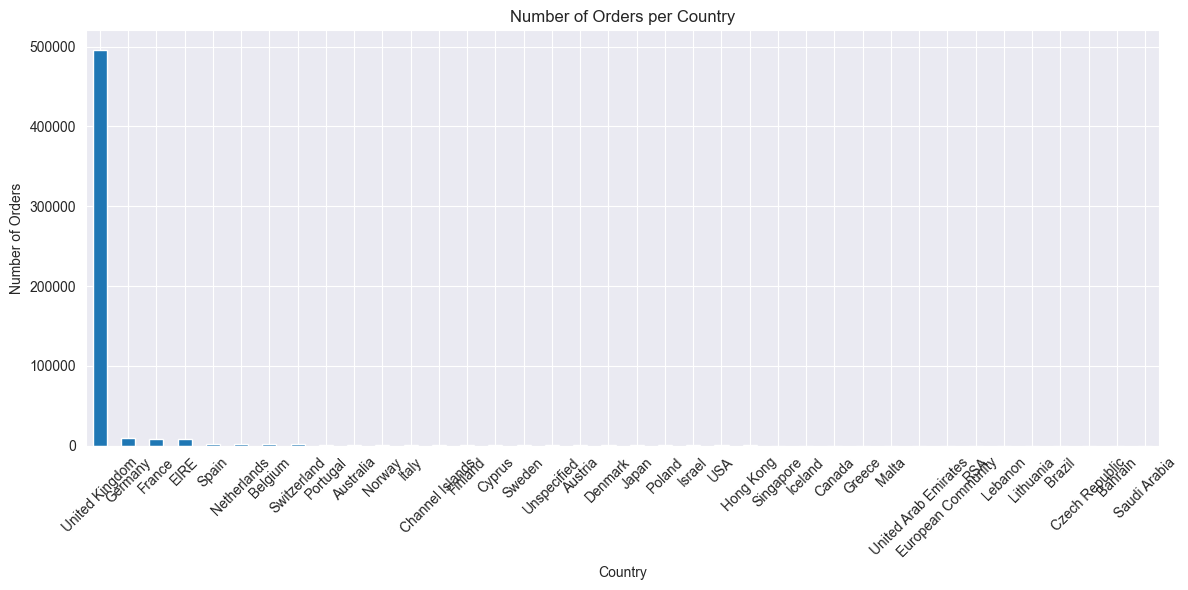

In [9]:
order_counts = df.groupby("Country").size().sort_values(ascending=False)

print(order_counts.head())

plt.figure(figsize=(12, 6))
order_counts.plot(kind="bar")
plt.title("Number of Orders per Country")
plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

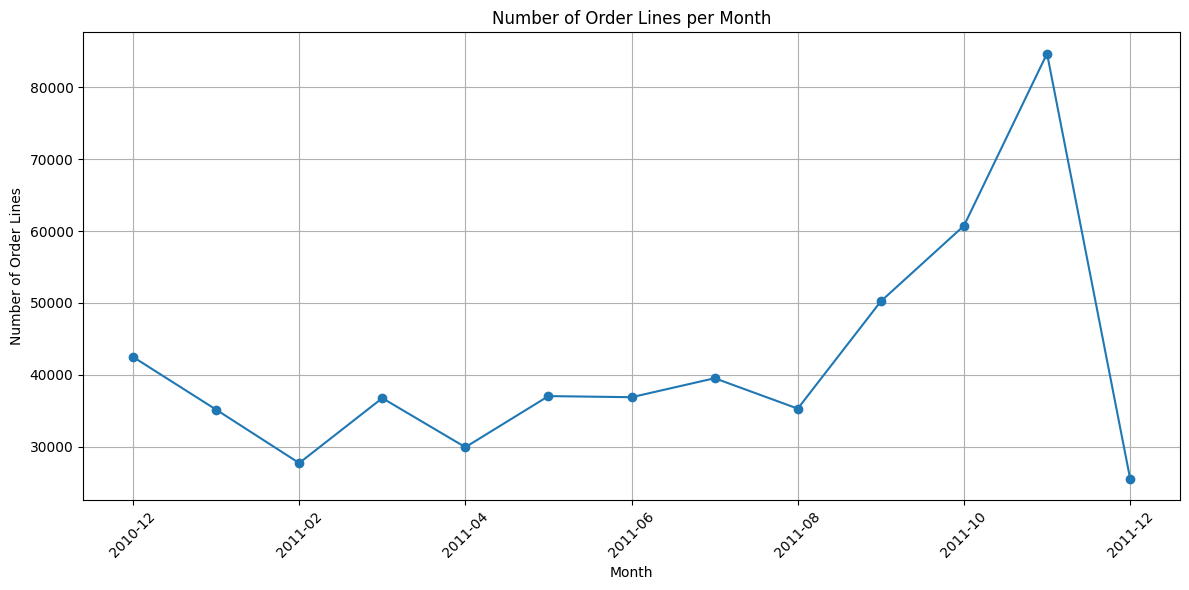

In [11]:
# Convert 'InvoiceDate' to datetime if it's not already
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Year-Month string for grouping
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# Count number of rows (order lines) per month
monthly_order_counts = df.groupby('YearMonth').size()

# Plotting
plt.figure(figsize=(12, 6))
monthly_order_counts.plot(kind='line', marker='o')
plt.title("Number of Order Lines per Month")
plt.xlabel("Month")
plt.ylabel("Number of Order Lines")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

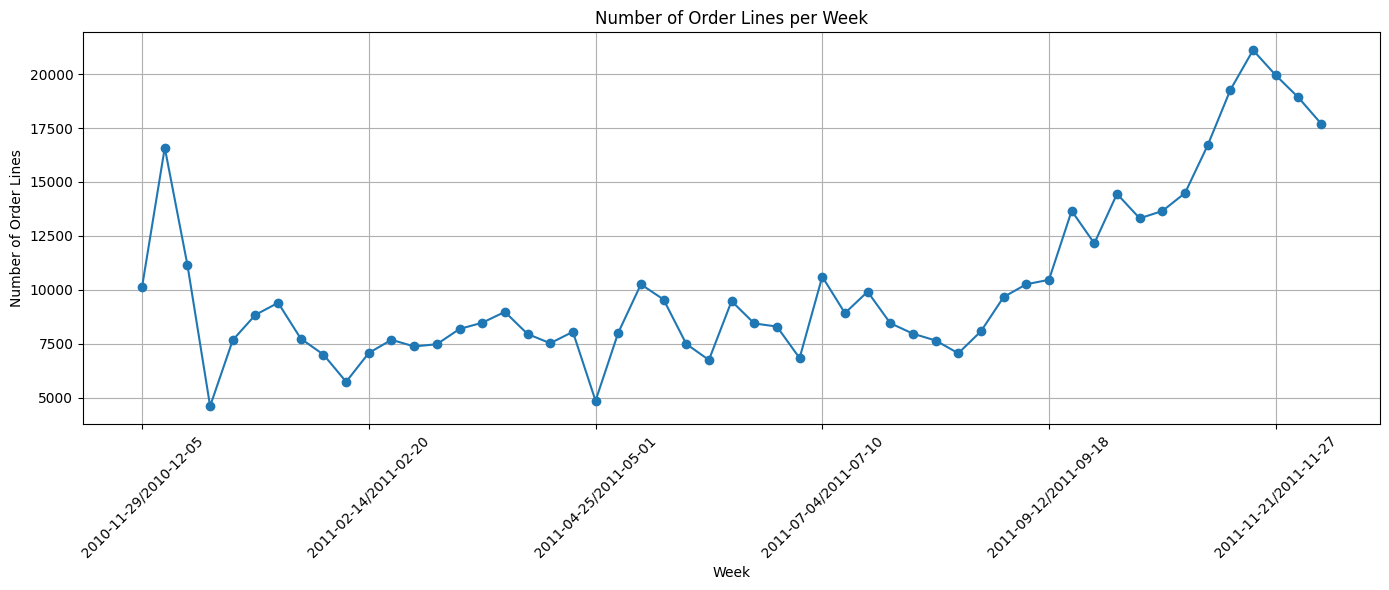

In [12]:
# Create a column for year-week (ISO format)
df['YearWeek'] = df['InvoiceDate'].dt.to_period('W').astype(str)

# Group by week and count order lines
weekly_order_counts = df.groupby('YearWeek').size()

# Plotting
plt.figure(figsize=(14, 6))
weekly_order_counts.plot(kind='line', marker='o')
plt.title("Number of Order Lines per Week")
plt.xlabel("Week")
plt.ylabel("Number of Order Lines")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Part2: Product-Specific Analysis:
In this section, we performed a detailed time series analysis for selected top-selling products to better understand their weekly sales behavior.

### Analyzing Top 10 Products by Order Line Count

In [ ]:
len(df['StockCode'].unique())

4070

In [10]:
# Count order lines per StockCode
stockcode_counts = df['StockCode'].value_counts().head(10)

# Convert to DataFrame
top_stockcodes = stockcode_counts.reset_index()
top_stockcodes.columns = ['StockCode', 'OrderLineCount']

# Map each StockCode to its most common Description
# (in case there are inconsistencies, pick the most frequent one)
desc_map = (
    df.groupby(['StockCode', 'Description']).size()
    .reset_index(name='count')
    .sort_values(['StockCode', 'count'], ascending=[True, False])
    .drop_duplicates('StockCode')
    .set_index('StockCode')['Description']
)

# Add Description column to the DataFrame
top_stockcodes['Description'] = top_stockcodes['StockCode'].map(desc_map)

# Display result
print(top_stockcodes)

  StockCode  OrderLineCount                         Description
0    85123A            2313  WHITE HANGING HEART T-LIGHT HOLDER
1     22423            2203            REGENCY CAKESTAND 3 TIER
2    85099B            2159             JUMBO BAG RED RETROSPOT
3     47566            1727                       PARTY BUNTING
4     20725            1639             LUNCH BAG RED RETROSPOT
5     84879            1502       ASSORTED COLOUR BIRD ORNAMENT
6     22720            1477   SET OF 3 CAKE TINS PANTRY DESIGN 
7     22197            1476                      POPCORN HOLDER
8     21212            1385     PACK OF 72 RETROSPOT CAKE CASES
9     20727            1350             LUNCH BAG  BLACK SKULL.


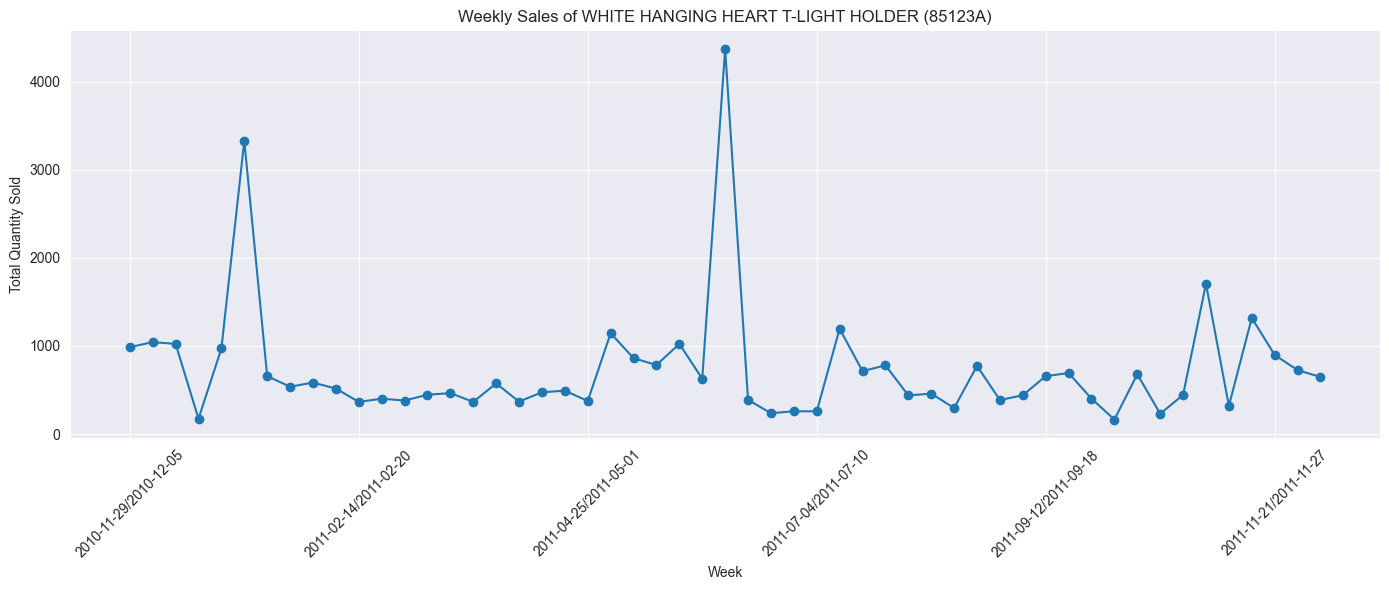

In [11]:
# Ensure InvoiceDate is datetime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Filter for StockCode 85123A
product_df = df[df['StockCode'] == '85123A'].copy()

# Create a 'YearWeek' column
product_df['YearWeek'] = product_df['InvoiceDate'].dt.to_period('W').astype(str)

# Group by week and sum the quantity
weekly_sales = product_df.groupby('YearWeek')['Quantity'].sum()

# Plotting
plt.figure(figsize=(14, 6))
weekly_sales.plot(kind='line', marker='o')
plt.title("Weekly Sales of WHITE HANGING HEART T-LIGHT HOLDER (85123A)")
plt.xlabel("Week")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📈 Weekly Sales of WHITE HANGING HEART T-LIGHT HOLDER (85123A)

This product shows two extreme sales spikes: one in **early December 2010** and another in **late May 2011**, with weekly sales exceeding 3,000 and 4,000 units respectively. These outliers likely reflect **bulk purchases from wholesalers** or **seasonal promotional campaigns**.

Aside from these peaks, weekly sales fluctuate between **300–1,200 units**, with some small increases observed again in **November 2011**, possibly tied to holiday restocking. The overall trend appears **irregular with high volatility**, suggesting demand is influenced by **special events or large one-time orders** rather than steady customer purchasing behavior.

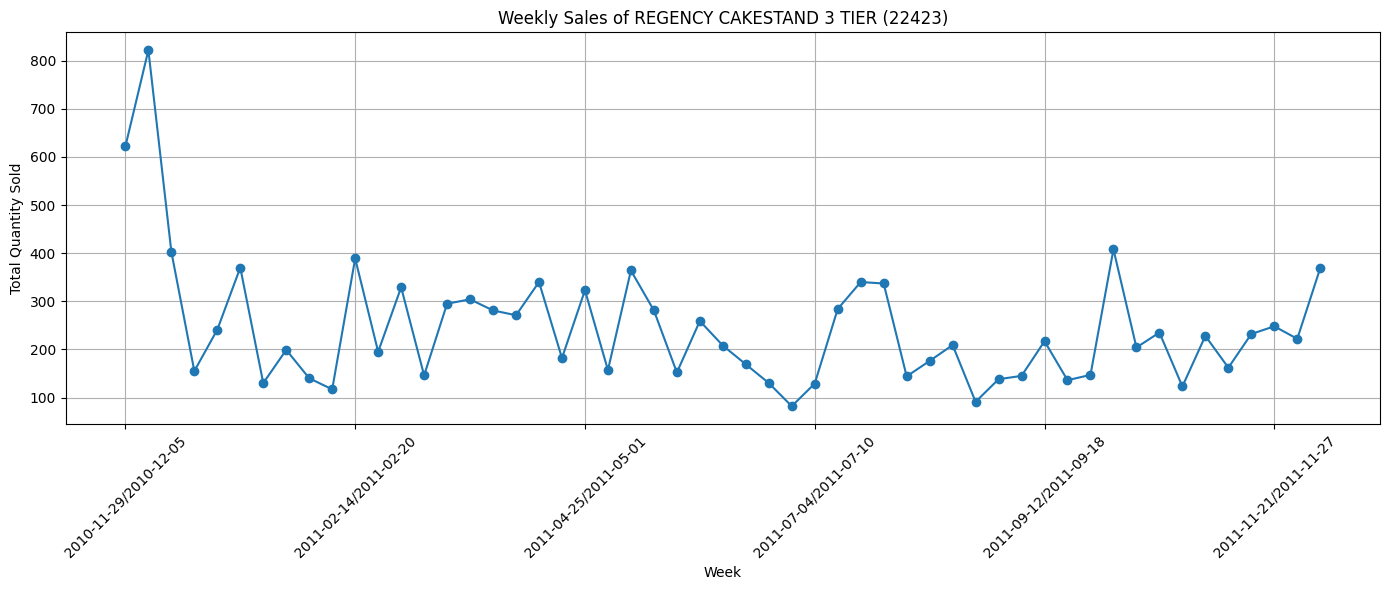

In [ ]:
# Filter for StockCode 2242d3
product_df = df[df['StockCode'] == 22423].copy()

# Create a 'YearWeek' column
product_df['YearWeek'] = product_df['InvoiceDate'].dt.to_period('W').astype(str)

# Group by week and sum the quantity
weekly_sales = product_df.groupby('YearWeek')['Quantity'].sum()

# Plotting
plt.figure(figsize=(14, 6))
weekly_sales.plot(kind='line', marker='o')
plt.title("Weekly Sales of REGENCY CAKESTAND 3 TIER (22423)")
plt.xlabel("Week")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📉 Weekly Sales of REGENCY CAKESTAND 3 TIER (22423)

The product shows an initial surge in weekly sales in early December 2010, peaking above 800 units—likely driven by holiday demand. Following this, sales drop significantly and stabilize between 150–350 units per week.

While there's no strong seasonality, we observe intermittent spikes (e.g., July and October 2011), possibly due to bulk orders or promotions. Overall, the trend appears **irregular but steady**, suggesting **moderate and consistent demand** with occasional uplifts.

### Weekly total revenue

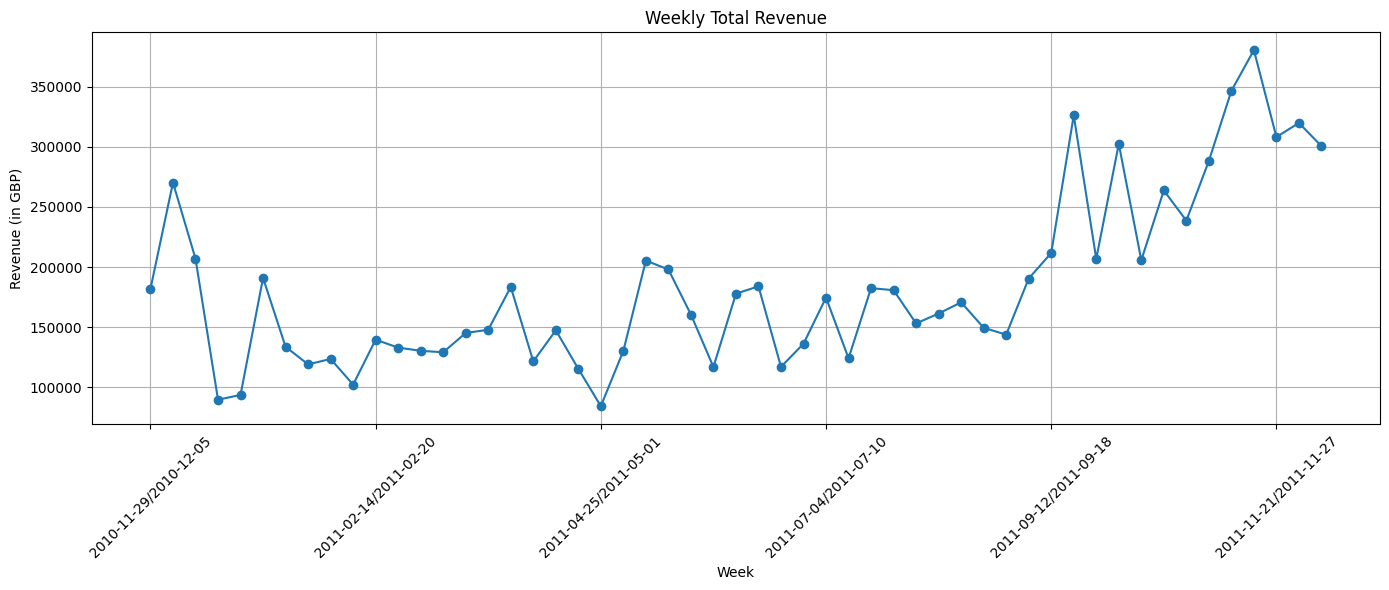

In [ ]:
# Create 'Revenue' column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Extract Year-Week period
df['YearWeek'] = df['InvoiceDate'].dt.to_period('W').astype(str)

# Group by week and sum revenue
weekly_revenue = df.groupby('YearWeek')['Revenue'].sum()

# Plotting
plt.figure(figsize=(14, 6))
weekly_revenue.plot(kind='line', marker='o')
plt.title("Weekly Total Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue (in GBP)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

##  Interpretation: Weekly Total Revenue Trend

The chart above visualizes the **weekly total revenue** generated from all product sales between December 2010 and December 2011.

###  Key Observations:

1. **Early Volatility (Dec 2010 – Feb 2011):**
   - The revenue shows high volatility at the beginning, with a peak around early December 2010 (likely due to holiday shopping).
   - A sharp drop follows, which may indicate the post-holiday lull.

2. **Stable Period (Mar 2011 – Aug 2011):**
   - From March through mid-August 2011, revenue stabilizes between **£130,000–£200,000** per week.
   - This suggests a relatively stable sales baseline, possibly due to recurring wholesale orders or regular customer behavior.

3. **Significant Growth in Late 2011:**
   - Starting around **September 2011**, we observe a sharp and consistent **upward trend** in weekly revenue.
   - This culminates in the highest weekly revenue exceeding **£370,000** around mid-November 2011.
   - Likely reasons:
     - B2B buyers preparing for holiday season restocking
     - New product launches or effective marketing campaigns
     - Potential sales events or discount promotions

4. **End-of-Year Plateau:**
   - Toward late November and early December 2011, revenue remains high but slightly fluctuates, possibly reflecting high demand balanced by supply limitations or fulfillment constraints.

---

###  Business Insights:

- **Seasonal Planning:** Late Q3 and Q4 are critical for revenue — the business should optimize stock, logistics, and staffing to capitalize on these months.
- **Inventory Forecasting:** The company should expect sharp spikes in revenue leading into the holiday season and plan purchases accordingly.
- **Marketing Opportunity:** Promotions aligned with these peak periods could further amplify revenue.



##  Part3: Different Time Series Model

To evaluate different time series forecasting models, we implemented a reusable function `forecast_and_compare()` that supports model training, prediction, and evaluation. It was applied to various business metrics, including:

- **Weekly Revenue**: Measures overall business performance
- **Weekly Product Sales**: Tracks item-level demand (e.g., StockCode 22423)
- **Weekly Order Count**: Reflects customer activity and operational load

The function compares four models:
- **ETS (Additive)**
- **ETS (Multiplicative)**
- **ARIMA (Non-Seasonal)**
- **ARIMA (Seasonal)**


In [14]:
def forecast_and_compare(df, date_col, value_col, seasonal_periods=12):
    df = df.copy()

    # Convert to datetime and resample to weekly (Monday)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).asfreq('D')  # Fill daily frequency
    df = df.resample('W-MON').sum()          # Resample to weekly frequency

    # Drop rows with missing values
    df = df.dropna()

    # Basic check for data length
    if len(df) < seasonal_periods * 2:
        raise ValueError(f"Not enough data for seasonal modeling. At least {seasonal_periods*2} points needed.")

    # Train-test split: last 1 week is test
    train_data = df.iloc[:-8][value_col]
    test_data = df.iloc[-8:][value_col]

    forecasts = {}
    metrics = {'RMSE': {}, 'MAE': {}, 'MAPE': {}}

    # ----------------------------
    # ETS Additive
    # ----------------------------
    try:
        if len(train_data) >= seasonal_periods * 2:
            ets_add = ExponentialSmoothing(train_data, trend='add', seasonal='add',
                                            seasonal_periods=seasonal_periods).fit()
            fcast = ets_add.forecast(len(test_data))
            forecasts['ETS-Add'] = fcast
        else:
            raise ValueError("Too little data for ETS-Add")
    except Exception as e:
        print("ETS-Add error:", e)
        forecasts['ETS-Add'] = pd.Series([np.nan] * len(test_data), index=test_data.index)

    # ----------------------------
    # ETS Multiplicative
    # ----------------------------
    try:
        corrected_train = train_data.copy()

        # Replace zeros and negative values with a small positive number
        corrected_train[corrected_train <= 0] = 1e-3

        if len(corrected_train) >= seasonal_periods * 2:
            ets_mul = ExponentialSmoothing(corrected_train, trend='mul', seasonal='mul',
                                        seasonal_periods=seasonal_periods).fit()
            fcast = ets_mul.forecast(len(test_data))
            forecasts['ETS-Mul'] = fcast
        else:
            raise ValueError("Too little data for ETS-Mul")
    except Exception as e:
        print("ETS-Mul error:", e)
        forecasts['ETS-Mul'] = pd.Series([np.nan] * len(test_data), index=test_data.index)

    # ----------------------------
    # ARIMA Non-Seasonal
    # ----------------------------
    try:
        arima_ns = pm.auto_arima(train_data, seasonal=False, stepwise=True,
                                 suppress_warnings=True, error_action='ignore')
        fcast = arima_ns.predict(n_periods=len(test_data))
        forecasts['ARIMA-NS'] = pd.Series(fcast, index=test_data.index)
    except Exception as e:
        print("ARIMA-NS error:", e)
        forecasts['ARIMA-NS'] = pd.Series([np.nan] * len(test_data), index=test_data.index)

    # ----------------------------
    # ARIMA Seasonal
    # ----------------------------
    try:
        if len(train_data) >= seasonal_periods * 2:
            arima_s = pm.auto_arima(train_data, seasonal=True, m=seasonal_periods, D=1, stepwise=True,
                                    suppress_warnings=True, error_action='ignore')
            fcast = arima_s.predict(n_periods=len(test_data))
            forecasts['ARIMA-S'] = pd.Series(fcast, index=test_data.index)
        else:
            raise ValueError("Too little data for seasonal ARIMA")
    except Exception as e:
        print("ARIMA-S error:", e)
        forecasts['ARIMA-S'] = pd.Series([np.nan] * len(test_data), index=test_data.index)

    # ----------------------------
    # Evaluate Metrics
    # ----------------------------
    for model_name, pred in forecasts.items():
        if pred.isnull().all():
            rmse = mae = mape = np.nan
        else:
            rmse = np.sqrt(mean_squared_error(test_data, pred))
            mae = mean_absolute_error(test_data, pred)
            mape = np.mean(np.abs((test_data - pred) / test_data)) * 100

        metrics['RMSE'][model_name] = rmse
        metrics['MAE'][model_name] = mae
        metrics['MAPE'][model_name] = mape

    # ----------------------------
    # Plot Forecast Comparison
    # ----------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(train_data.index, train_data.values, label='Train', linestyle='--', color='gray')
    plt.plot(test_data.index, test_data.values, label='Actual', linewidth=2, color='blue')
    for name, pred in forecasts.items():
        plt.plot(pred.index, pred.values, label=name)
    plt.title("Forecast Comparison on Final Weeks")
    plt.xlabel("Date")
    plt.ylabel(value_col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(metrics)

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Group by weekly period using PeriodIndex
df['WeekPeriod'] = df['InvoiceDate'].dt.to_period('W')
weekly_revenue = df.groupby('WeekPeriod')['Revenue'].sum()

# Convert PeriodIndex to Timestamp (end of week) for modeling
weekly_revenue.index = weekly_revenue.index.to_timestamp(how='end')

# Create a two-column DataFrame: Date + Revenue
weekly_revenue_df = weekly_revenue.reset_index()
weekly_revenue_df.columns = ['Date', 'Revenue']

/Library/Python/3.9/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Library/Python/3.9/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Library/Python/3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Python/3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Python/3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Python/3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' w

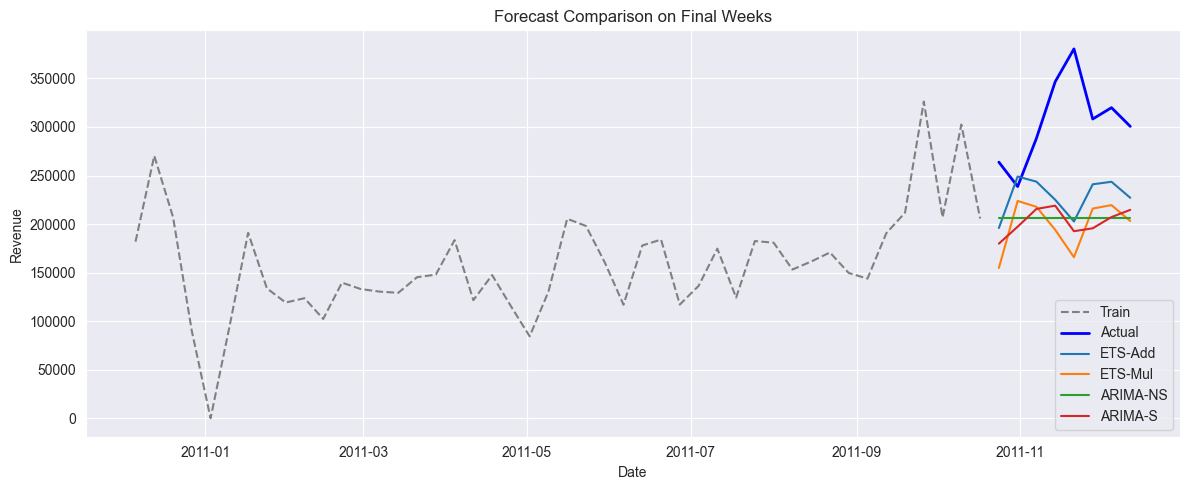


📊 Weekly Forecast Model Evaluation:
               RMSE        MAE   MAPE
ETS-Add    92742.11   79886.19  24.68
ETS-Mul   119599.01  106425.59  33.26
ARIMA-NS  108471.56  100053.37  31.43
ARIMA-S   110873.71  103075.55  32.61


In [16]:
results = forecast_and_compare(weekly_revenue_df, 'Date', 'Revenue')
print("\n Weekly Forecast Model Evaluation:")
print(results.round(2))

#### Interpretation:

- ETS-Additive performs the best across all metrics, indicating that revenue has additive seasonality rather than multiplicative growth behavior.

- Both ARIMA models underperform ETS-Add, possibly due to not fully capturing trend or external effects.

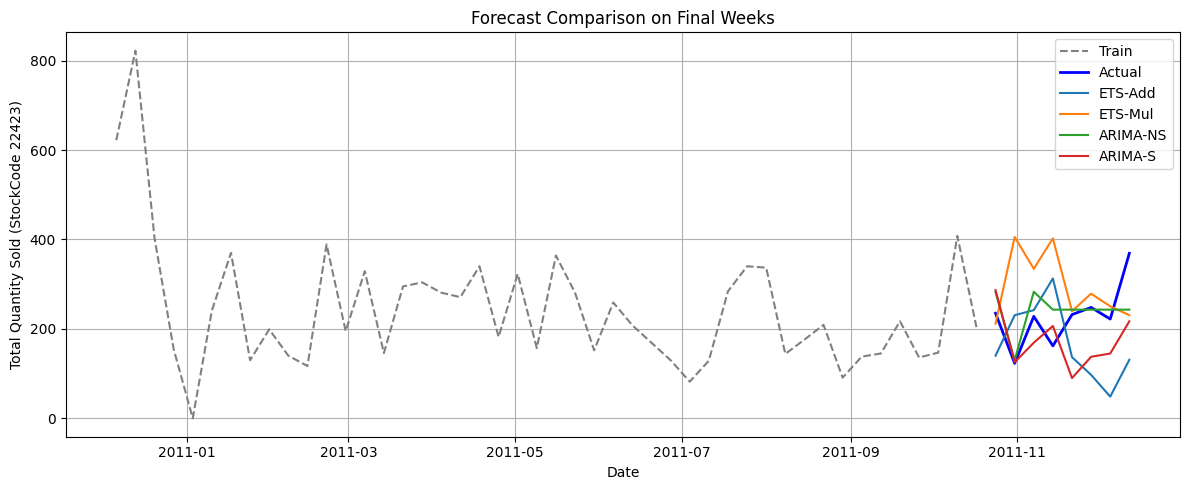


 Weekly Forecast Model Evaluation:
            RMSE     MAE   MAPE
ETS-Add   142.30  128.06  58.93
ETS-Mul   145.94  107.22  62.58
ARIMA-NS   59.48   44.13  18.78
ARIMA-S    93.22   79.86  32.36


In [ ]:
# Step 1: Convert string YearWeek to PeriodIndex
weekly_sales.index = pd.PeriodIndex(weekly_sales.index, freq='W')

# Step 2: Convert PeriodIndex to Timestamp (e.g., end of each week)
weekly_sales.index = weekly_sales.index.to_timestamp(how='end')

# Step 3: Convert to DataFrame with 'Date' and 'Quantity' columns
weekly_sales_df = weekly_sales.reset_index()
weekly_sales_df.columns = ['Date', 'Total Quantity Sold (StockCode 22423)']

results = forecast_and_compare(weekly_sales_df, 'Date', 'Total Quantity Sold (StockCode 22423)')
print("\n📊 Weekly Forecast Model Evaluation:")
print(results.round(2))

#### Interpretation:
- Again, ETS-Add outperforms the rest, suggesting that weekly demand is better captured through additive trend/seasonality, not multiplicative.

- ARIMA models perform reasonably but less effectively than ETS-Add.

/Users/lijunyan/.pyenv/versions/3.8.12/lib/python3.8/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/lijunyan/.pyenv/versions/3.8.12/lib/python3.8/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


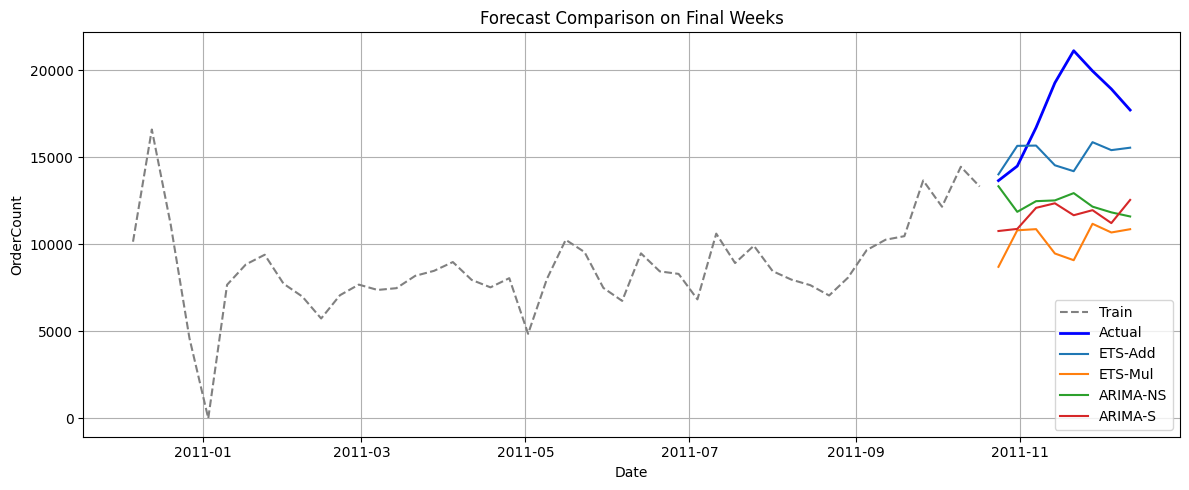

             RMSE      MAE   MAPE
ETS-Add   3650.42  2997.28  15.69
ETS-Mul   7943.30  7521.04  41.34
ARIMA-NS  5975.68  5387.58  28.83
ARIMA-S   6419.43  6042.28  33.04


In [ ]:
# Step 1: Convert string YearWeek to proper weekly PeriodIndex
weekly_order_counts.index = pd.PeriodIndex(weekly_order_counts.index, freq='W')

# Step 2: Convert PeriodIndex to Timestamp (we use end of each week)
weekly_order_counts.index = weekly_order_counts.index.to_timestamp(how='end')

# Step 3: Convert to DataFrame with appropriate column names
weekly_order_counts_df = weekly_order_counts.reset_index()
weekly_order_counts_df.columns = ['Date', 'OrderCount']

results = forecast_and_compare(weekly_order_counts_df, 'Date', 'OrderCount')
print(results.round(2))

#### Interpretation:

- ETS-Add is again the top performer, with the lowest error across all metrics.

- ETS-Multiplicative performs poorly, suggesting that order volume does not scale proportionally with seasonality (multiplicative model is not suitable).

##  Conclusion:

In this project, we developed a forecasting pipeline to analyze and predict key retail metrics using time series modeling. By transforming transactional data into weekly aggregates, we evaluated multiple forecasting methods—ETS (Additive & Multiplicative), ARIMA (Seasonal & Non-Seasonal)—across three business targets: total revenue, individual product sales, and total order count.

### 🔍 Key Takeaways:

- **ETS Additive consistently outperformed other models** across all metrics (RMSE, MAE, MAPE), indicating that the underlying trends and seasonality in this dataset are best captured in an additive manner.
- **Multiplicative models performed poorly**, especially for order count and product-level sales, suggesting that the time series do not exhibit proportional seasonal growth.
- **ARIMA models offered competitive results**, particularly the non-seasonal variant, but still fell short in accuracy compared to ETS-Add.

###  Business Implications:

- **Revenue forecasting** using ETS-Add enables more confident budgeting and cash flow planning, especially ahead of peak seasons.
- **Product-level forecasts** help inform inventory control and procurement decisions.
- **Order volume predictions** support operational staffing, packaging, and fulfillment strategies.

By identifying reliable models and extracting demand patterns, this approach enables data-driven decision-making to optimize retail performance.

